In [1]:
from pathlib import Path
import sys


SCENARIO_DIR = Path.cwd()
REPO_ROOT = SCENARIO_DIR.parents[2]
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from modules.security.models import SecurityModelType
from pipelines.routing import CGRYenRouting
from pipelines.simulation import SimulationPipeline


SERIES_COLORS = {
    SecurityModelType.HOP_BY_HOP: "#0f4c5c",
    SecurityModelType.END_TO_END: "#e36414",
    SecurityModelType.EDGE_BY_EDGE: "#6a994e",
    SecurityModelType.EDGE_TO_EDGE: "#8d0801",
}

max_routes = 1
pipeline = SimulationPipeline()

result = pipeline.run(
    cp_path=str(SCENARIO_DIR / "contact_plan.json"),
    topology_path=str(SCENARIO_DIR / "topology.json"),
    security_models=tuple(SecurityModelType),
    curr_time=0,
    routing_algorithm=CGRYenRouting(max_routes=max_routes),
)
result_s = pipeline.run(
    cp_path=str(SCENARIO_DIR / "contact_plan.json"),
    topology_path=str(SCENARIO_DIR / "topology.json"),
    security_models=tuple(SecurityModelType),
    curr_time=0,
    routing_algorithm=CGRYenRouting(max_routes=max_routes),
    symmetric_keys=True
)

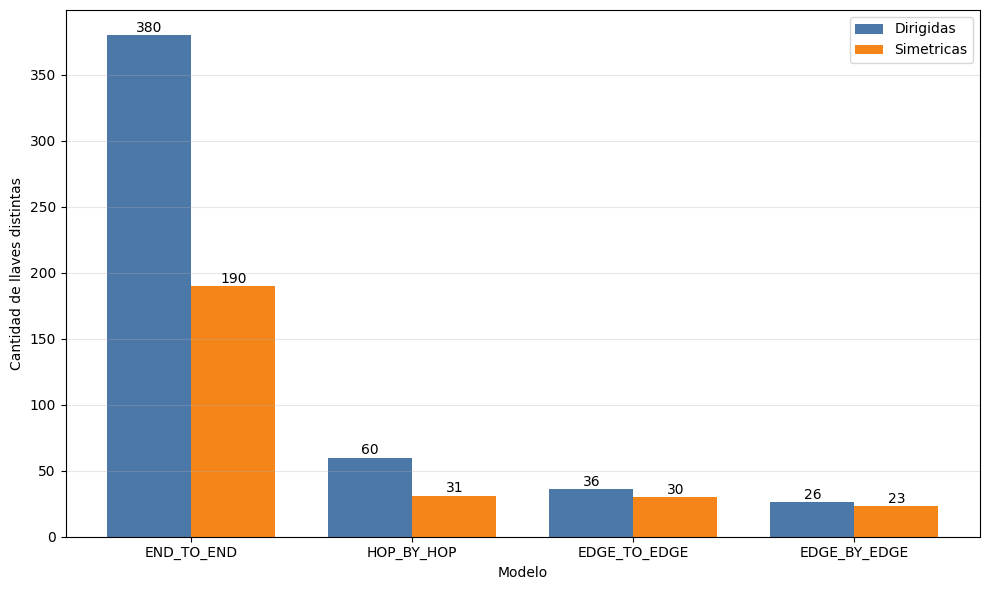

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

from modules.security.models import SecurityModelType
from pipelines.route_activation import RouteActivationPlanner

planner = RouteActivationPlanner()

rows = []
for label, sim_result in [("Dirigidas", result), ("Simetricas", result_s)]:
    for model in SecurityModelType:
        planning = planner.build_for_model(sim_result.security, model=model)
        rows.append(
            {
                "mode": label,
                "model": model.name,
                "unique_keys": len(planning.key_scopes),
            }
        )

df = pd.DataFrame(rows)

pivot = df.pivot(index="model", columns="mode", values="unique_keys").reset_index()
pivot = pivot.sort_values("Dirigidas", ascending=False)

x = range(len(pivot))
width = 0.38

plt.figure(figsize=(10, 6))
plt.bar(
    [i - width / 2 for i in x],
    pivot["Dirigidas"],
    width=width,
    label="Dirigidas",
    color="#4c78a8",
)
plt.bar(
    [i + width / 2 for i in x],
    pivot["Simetricas"],
    width=width,
    label="Simetricas",
    color="#f58518",
)

plt.xticks(list(x), pivot["model"])
plt.ylabel("Cantidad de llaves distintas")
plt.xlabel("Modelo")
plt.grid(axis="y", alpha=0.3)
plt.legend()

for i, value in enumerate(pivot["Dirigidas"]):
    plt.text(i - width / 2, value + 0.3, str(value), ha="center", va="bottom")

for i, value in enumerate(pivot["Simetricas"]):
    plt.text(i + width / 2, value + 0.3, str(value), ha="center", va="bottom")

plt.tight_layout()
plt.show()


In [24]:
from pipelines.route_activation import RouteActivationPlanner
from modules.security.models import SecurityModelType

def print_pair_comparison(result_dir, result_sym, pair):
    planner = RouteActivationPlanner()
    models = [
        # SecurityModelType.HOP_BY_HOP,
        # SecurityModelType.END_TO_END,
        SecurityModelType.EDGE_BY_EDGE,
        SecurityModelType.EDGE_TO_EDGE,
    ]

    route_prefix = f"{pair[0]}->{pair[1]}:"

    route_dir = result_dir.annotation.annotated_routes_by_pair[pair][0]
    route_sym = result_sym.annotation.annotated_routes_by_pair[pair][0]

    print(f"Pair: {pair[0]} -> {pair[1]}")
    print(f"Nodes:      {', '.join(f'{node:3d}' for node in route_dir.node_path)}")
    print(f"Networks:   {', '.join(f'{net:3d}' for net in route_dir.network_path)}")
    print(f"Boundaries: {route_dir.boundary_crossings}")
    print()

    for model in models:
        raw_dir = result_dir.security.plans_by_model[model][pair][0].key_requirements
        raw_sym = result_sym.security.plans_by_model[model][pair][0].key_requirements

        planning_dir = planner.build_for_model(result_dir.security, model=model)
        planning_sym = planner.build_for_model(result_sym.security, model=model)

        norm_dir = next(
            req.required_key_scopes
            for req in planning_dir.route_requirements
            if req.route_id.startswith(route_prefix)
        )
        norm_sym = next(
            req.required_key_scopes
            for req in planning_sym.route_requirements
            if req.route_id.startswith(route_prefix)
        )

        print(f"{model.name}")
        # print(f"  raw directed:   {' '.join(str(req) for req in raw_dir)}")
        # print(f"  raw symmetric:  {' '.join(str(req) for req in raw_sym)}")
        print(f"  norm directed:  {' '.join(str(scope) for scope in norm_dir)}")
        print(f"  norm symmetric: {' '.join(str(scope) for scope in norm_sym)}")
        print()


In [25]:
print_pair_comparison(result, result_s, (1, 20))
print_pair_comparison(result, result_s, (20, 1))

Pair: 1 -> 20
Nodes:        1,   6,  11,  16,  17,  18,  19,  20
Networks:     1,   2,   3,   4,   4,   4,   4,   4
Boundaries: (1->6, 6->11, 11->16)

EDGE_BY_EDGE
  norm directed:  GROUP_TO_GROUP(1->2) GROUP_TO_GROUP(2->3) GROUP_TO_GROUP(3->4) NODE_TO_GROUP(16->4)
  norm symmetric: GROUP_TO_GROUP(1->2) GROUP_TO_GROUP(2->3) GROUP_TO_GROUP(3->4) NODE_TO_GROUP(16->4)

EDGE_TO_EDGE
  norm directed:  GROUP_TO_GROUP(1->4) NODE_TO_GROUP(16->4)
  norm symmetric: GROUP_TO_GROUP(1->4) NODE_TO_GROUP(16->4)

Pair: 20 -> 1
Nodes:       20,  19,  18,  17,  16,  11,   6,   1
Networks:     4,   4,   4,   4,   4,   3,   2,   1
Boundaries: (16->11, 11->6, 6->1)

EDGE_BY_EDGE
  norm directed:  NODE_TO_GROUP(20->4) GROUP_TO_GROUP(4->3) GROUP_TO_GROUP(3->2) GROUP_TO_GROUP(2->1)
  norm symmetric: NODE_TO_GROUP(20->4) GROUP_TO_GROUP(3->4) GROUP_TO_GROUP(2->3) GROUP_TO_GROUP(1->2)

EDGE_TO_EDGE
  norm directed:  NODE_TO_GROUP(20->4) GROUP_TO_GROUP(4->1)
  norm symmetric: NODE_TO_GROUP(20->4) GROUP_TO_GROUP(1

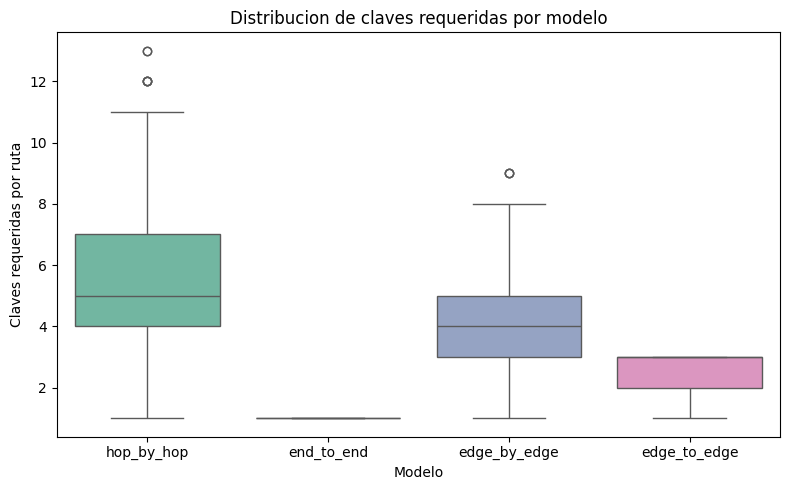

In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

rows = []

for model, plans_by_pair in result_s.security.plans_by_model.items():
    for pair, plans in plans_by_pair.items():
        for plan in plans:
            unique_scopes = {req.scope for req in plan.key_requirements}
            rows.append(
                {
                    "model": model.name.lower(),
                    "pair": f"{pair[0]}->{pair[1]}",
                    "route": f"{pair[0]}->{pair[1]}:{plan.route_id}",
                    "required_keys": len(unique_scopes),
                }
            )

df_keys = pd.DataFrame(rows)
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_keys,
    x="model",
    y="required_keys",
    hue="model",
    dodge=False,
    palette="Set2",
    legend=False,
)
# sns.stripplot(
#     data=df_keys,
#     x="model",
#     y="required_keys",
#     color="black",
#     alpha=0.35,
#     size=3,
# )
plt.title("Distribucion de claves requeridas por modelo")
plt.xlabel("Modelo")
plt.ylabel("Claves requeridas por ruta")
plt.tight_layout()
plt.show()


## Maximizar rutas sujeto a presupuesto de llaves

:::: {layout="[0.5, 0.5]"}

:::{#firstcol}
\begin{aligned}
P &: \text{conjunto de pares origen-destino alcanzables de la red} \\
R_p &: \text{conjunto de rutas candidatas para el par } p \in P \\
R &= \bigcup_{p \in P} R_p \\
K &: \text{conjunto de llaves candidatas disponibles} \\
S_r &\subseteq K : \text{conjunto de llaves requeridas por la ruta } r \in R \\
B &: \text{presupuesto máximo de llaves activas} \\
\end{aligned}
:::

:::{#secondcol}
\begin{aligned}
\max \quad & \sum_{r \in R} x_r \\
\text{s.a.} \quad
& \sum_{k \in K} y_k \le B \\
& \sum_{k \in S_r} y_k \ge |S_r|\,x_r \qquad \forall r \in R \\
& x_r \in \{0,1\} \qquad \forall r \in R \\
& y_k \in \{0,1\} \qquad \forall k \in K
\end{aligned}
:::


::::


In [26]:
import pandas as pd

df_m1 = pd.DataFrame()
for sec_model in SERIES_COLORS.keys():
    from models.model1_max_routes import solve_for_security_model
    
    df_m1 = pd.concat([df_m1,solve_for_security_model(result_s, sec_model)])

Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2821306
Academic license 2821306 - for non-commercial use only - registered to ra___@unc.edu.ar


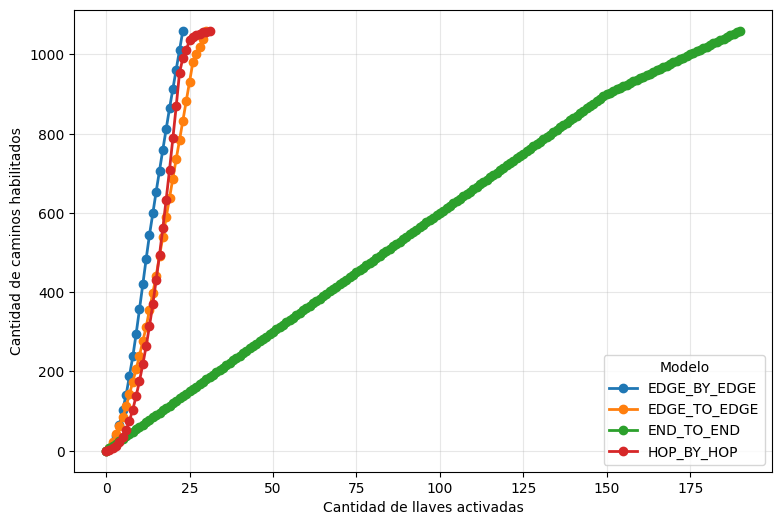

In [27]:
#| echo: false
import matplotlib.pyplot as plt
plt.figure(figsize=(9, 6))

for model_name, group in df_m1.groupby("model"):
    group = group.sort_values("selected_keys")
    plt.plot(
        group["selected_keys"],
        group["selected_routes"],
        marker="o",
        linewidth=2,
        label=model_name,
    )

plt.xlabel("Cantidad de llaves activadas")
plt.ylabel("Cantidad de caminos habilitados")
# plt.title("Llaves activadas vs caminos habilitados por modelo")
plt.grid(True, alpha=0.3)
plt.legend(title="Modelo")
plt.show()

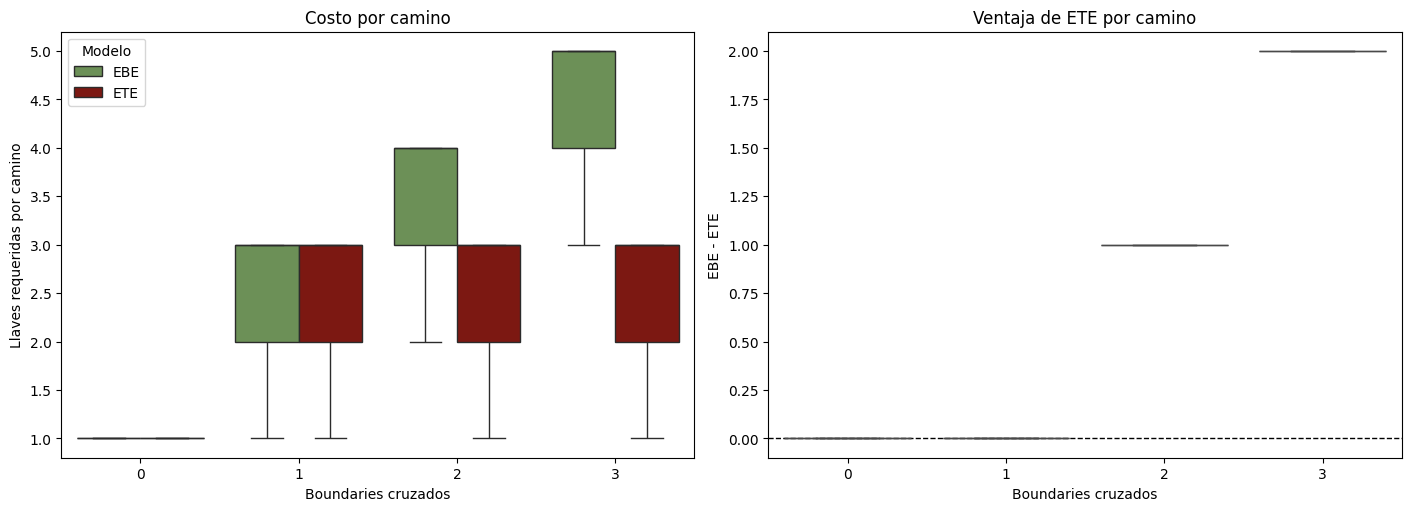

Chequeo: cantidad de caminos donde ETE usa más llaves que EBE: 0


In [35]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from modules.security.models import SecurityModelType

rows = []

for pair in result.routing.pairs:
    route = result.annotation.annotated_routes_by_pair[pair][0]
    boundaries_crossed = len(route.boundary_crossings)

    ebe_plan = result.security.plans_by_model[SecurityModelType.EDGE_BY_EDGE][pair][0]
    ete_plan = result.security.plans_by_model[SecurityModelType.EDGE_TO_EDGE][pair][0]

    ebe_keys = len({req.scope for req in ebe_plan.key_requirements})
    ete_keys = len({req.scope for req in ete_plan.key_requirements})

    rows.append({
        "pair": f"{pair[0]}->{pair[1]}",
        "boundaries_crossed": boundaries_crossed,
        "EBE": ebe_keys,
        "ETE": ete_keys,
        "delta_ebe_minus_ete": ebe_keys - ete_keys,
    })

df_paths = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

plot_df = df_paths.melt(
    id_vars=["pair", "boundaries_crossed"],
    value_vars=["EBE", "ETE"],
    var_name="model",
    value_name="required_keys",
)

sns.boxplot(
    data=plot_df,
    x="boundaries_crossed",
    y="required_keys",
    hue="model",
    palette={"EBE": "#6a994e", "ETE": "#8d0801"},
    ax=axes[0],
)
axes[0].set_xlabel("Boundaries cruzados")
axes[0].set_ylabel("Llaves requeridas por camino")
axes[0].set_title("Costo por camino")
axes[0].legend(title="Modelo")

sns.boxplot(
    data=df_paths,
    x="boundaries_crossed",
    y="delta_ebe_minus_ete",
    color="#4c78a8",
    ax=axes[1],
)
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_xlabel("Boundaries cruzados")
axes[1].set_ylabel("EBE - ETE")
axes[1].set_title("Ventaja de ETE por camino")

plt.show()

print("Chequeo: cantidad de caminos donde ETE usa más llaves que EBE:",
      (df_paths["delta_ebe_minus_ete"] < 0).sum())


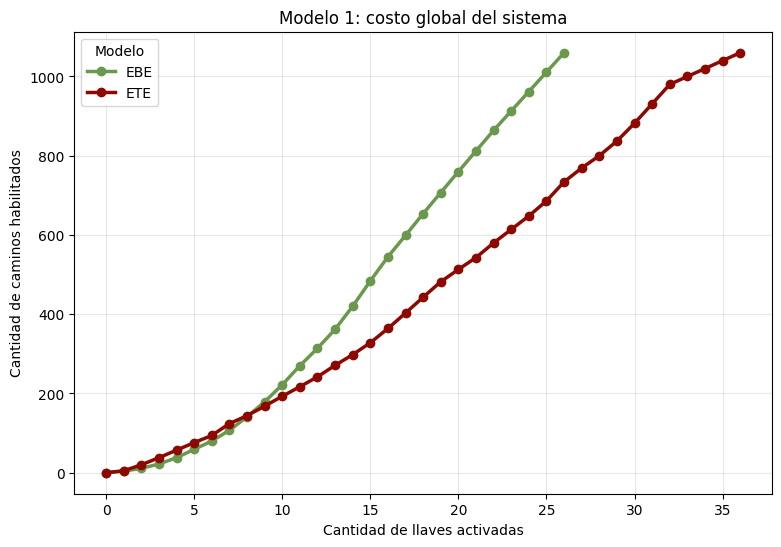

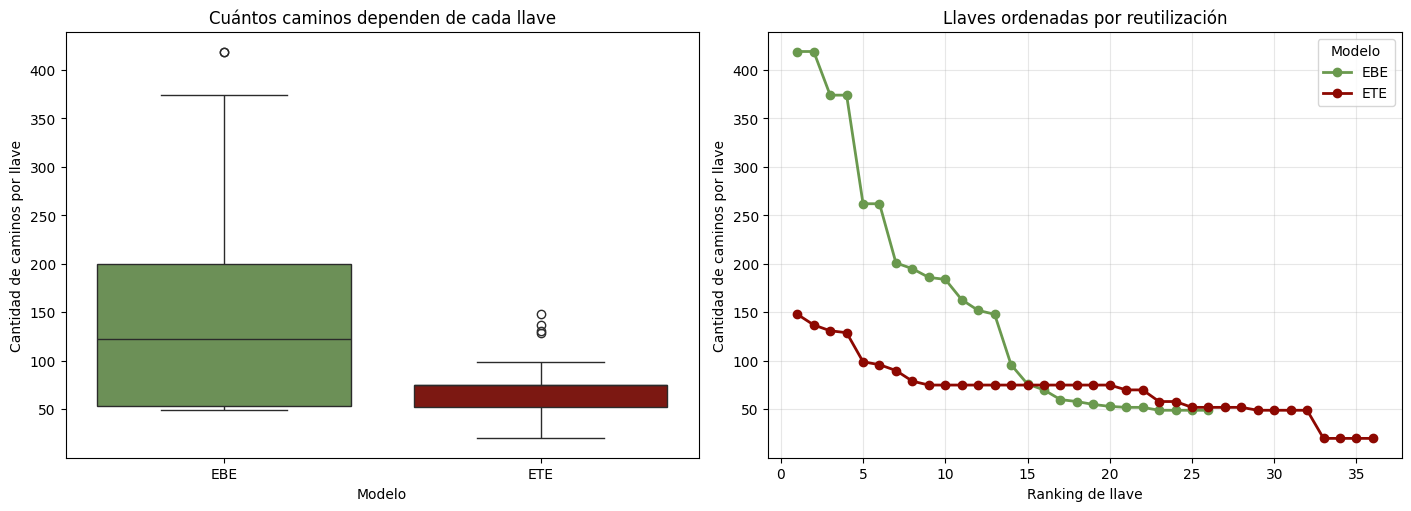

,mean,median,max
model,,,
EBE,157.961538,122.0,419.0
ETE,70.805556,75.0,148.0


In [39]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from modules.security.models import SecurityModelType
from pipelines.route_activation import RouteActivationPlanner

rows = []

for sec_model, label in [
    (SecurityModelType.EDGE_BY_EDGE, "EBE"),
    (SecurityModelType.EDGE_TO_EDGE, "ETE"),
]:
    planning = RouteActivationPlanner().build_for_model(result.security, model=sec_model)

    routes_per_key = {scope: 0 for scope in planning.key_scopes}
    for req in planning.route_requirements:
        for scope in req.required_key_scopes:
            routes_per_key[scope] += 1

    for scope, coverage in routes_per_key.items():
        rows.append({
            "model": label,
            "scope": str(scope),
            "routes_covered": coverage,
        })

df_key_coverage = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

sns.boxplot(
    data=df_key_coverage,
    x="model",
    y="routes_covered",
    hue="model",
    dodge=False,
    palette={"EBE": "#6a994e", "ETE": "#8d0801"},
    legend=False,
    ax=axes[0],
)
axes[0].set_title("Cuántos caminos dependen de cada llave")
axes[0].set_xlabel("Modelo")
axes[0].set_ylabel("Cantidad de caminos por llave")

for model, color in [("EBE", "#6a994e"), ("ETE", "#8d0801")]:
    top = (
        df_key_coverage[df_key_coverage["model"] == model]
        .sort_values("routes_covered", ascending=False)
        .reset_index(drop=True)
    )
    top["rank"] = top.index + 1
    axes[1].plot(top["rank"], top["routes_covered"], marker="o", linewidth=2, color=color, label=model)

axes[1].set_title("Llaves ordenadas por reutilización")
axes[1].set_xlabel("Ranking de llave")
axes[1].set_ylabel("Cantidad de caminos por llave")
axes[1].legend(title="Modelo")
axes[1].grid(True, alpha=0.3)

plt.show()

display(
    df_key_coverage.groupby("model")["routes_covered"]
    .describe()[["mean", "50%", "max"]]
    .rename(columns={"50%": "median"})
)


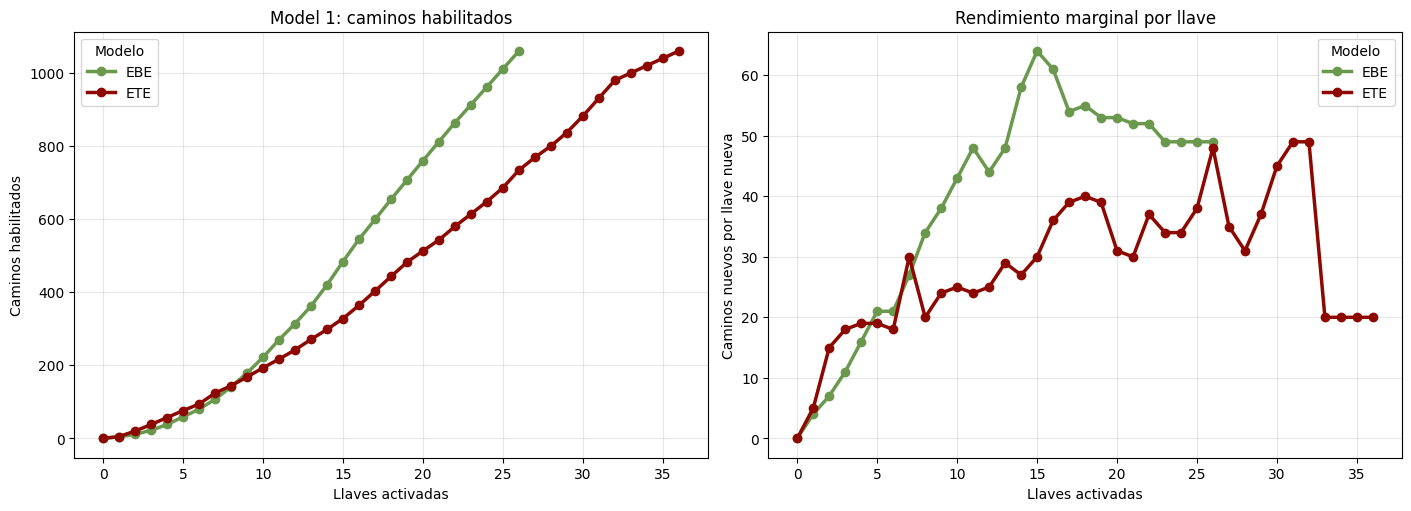

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

plot_models = ["EDGE_BY_EDGE", "EDGE_TO_EDGE"]
plot_labels = {"EDGE_BY_EDGE": "EBE", "EDGE_TO_EDGE": "ETE"}
plot_colors = {"EDGE_BY_EDGE": "#6a994e", "EDGE_TO_EDGE": "#8d0801"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

for model_name in plot_models:
    g = df_m1[df_m1["model"] == model_name].sort_values("selected_keys").copy()
    g["delta_routes"] = g["selected_routes"].diff().fillna(g["selected_routes"])
    g["delta_keys"] = g["selected_keys"].diff().fillna(g["selected_keys"].replace(0, 1))
    g["routes_per_new_key"] = g["delta_routes"] / g["delta_keys"].replace(0, 1)

    axes[0].plot(
        g["selected_keys"],
        g["selected_routes"],
        marker="o",
        linewidth=2.5,
        color=plot_colors[model_name],
        label=plot_labels[model_name],
    )

    axes[1].plot(
        g["selected_keys"],
        g["routes_per_new_key"],
        marker="o",
        linewidth=2.5,
        color=plot_colors[model_name],
        label=plot_labels[model_name],
    )

axes[0].set_title("Model 1: caminos habilitados")
axes[0].set_xlabel("Llaves activadas")
axes[0].set_ylabel("Caminos habilitados")
axes[0].legend(title="Modelo")
axes[0].grid(True, alpha=0.3)

axes[1].set_title("Rendimiento marginal por llave")
axes[1].set_xlabel("Llaves activadas")
axes[1].set_ylabel("Caminos nuevos por llave nueva")
axes[1].legend(title="Modelo")
axes[1].grid(True, alpha=0.3)

plt.show()


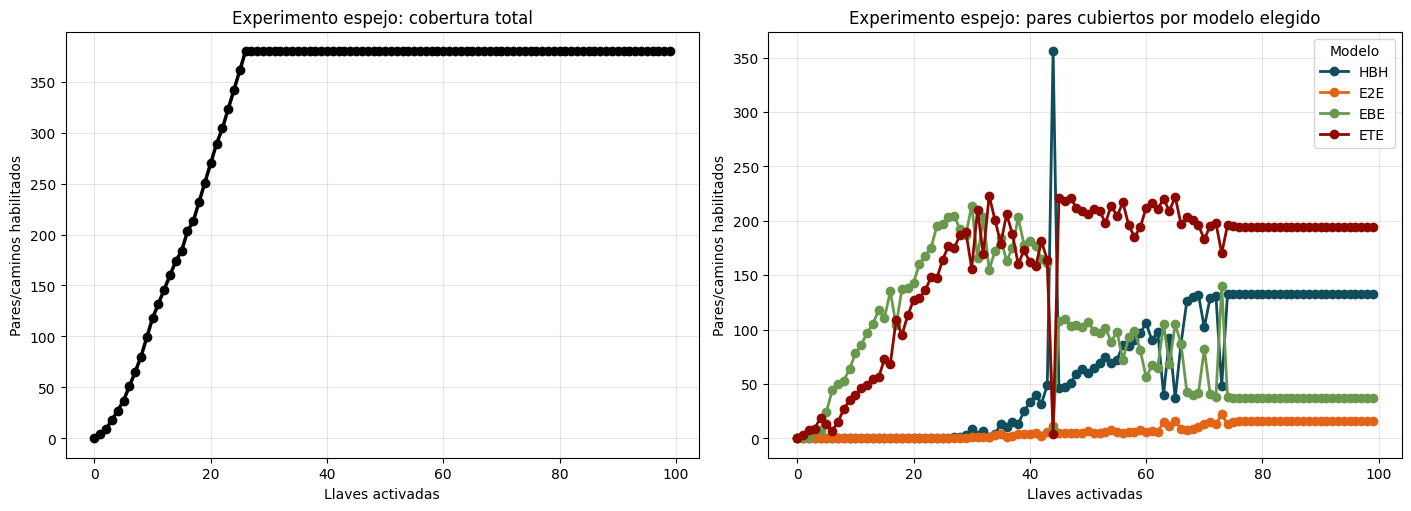

In [50]:
import gurobipy as gp
import pandas as pd
from gurobipy import GRB

from modules.security.models import SecurityModelType

def solve_mirror_model1_one_route_per_pair(result, max_keys):
    all_models = list(SecurityModelType)

    pair_model_scopes = {}
    all_scopes = set()

    for pair in result.security.pairs:
        for model in all_models:
            plans = result.security.plans_by_model[model][pair]
            if not plans:
                continue

            plan = plans[0]
            scopes = tuple(dict.fromkeys(req.scope for req in plan.key_requirements))
            pair_model_scopes[(pair, model)] = scopes
            all_scopes.update(scopes)

    all_scopes = list(all_scopes)

    mdl = gp.Model("mirror_model1_one_route_per_pair")
    mdl.setParam("OutputFlag", 0)

    y = {
        scope: mdl.addVar(vtype=GRB.BINARY, name=f"key[{i}]")
        for i, scope in enumerate(all_scopes)
    }

    x = {}
    for (pair, model), scopes in pair_model_scopes.items():
        x[(pair, model)] = mdl.addVar(
            vtype=GRB.BINARY,
            name=f"x[{pair[0]}->{pair[1]},{model.name}]"
        )

    mdl.update()

    for pair in result.security.pairs:
        vars_for_pair = [
            x[(pair, model)]
            for model in all_models
            if (pair, model) in x
        ]
        if vars_for_pair:
            mdl.addConstr(
                gp.quicksum(vars_for_pair) <= 1,
                name=f"one_model[{pair[0]}->{pair[1]}]"
            )

    for (pair, model), scopes in pair_model_scopes.items():
        if len(scopes) == 0:
            continue
        mdl.addConstr(
            gp.quicksum(y[s] for s in scopes) >= len(scopes) * x[(pair, model)],
            name=f"keys_for[{pair[0]}->{pair[1]},{model.name}]"
        )

    mdl.addConstr(gp.quicksum(y.values()) <= max_keys, name="budget")
    mdl.setObjective(gp.quicksum(x.values()), GRB.MAXIMIZE)

    mdl.optimize()

    selected_keys = [scope for scope, var in y.items() if var.X > 0.5]

    selected_assignments = [
        {
            "src": pair[0],
            "dst": pair[1],
            "model": model.name,
            "required_scopes_count": len(pair_model_scopes[(pair, model)]),
        }
        for (pair, model), var in x.items()
        if var.X > 0.5
    ]

    if selected_assignments:
        df_selected = (
            pd.DataFrame(selected_assignments)
            .sort_values(["src", "dst"])
            .reset_index(drop=True)
        )
    else:
        df_selected = pd.DataFrame(
            columns=["src", "dst", "model", "required_scopes_count"]
        )

    summary = {
        "max_keys": max_keys,
        "selected_pairs": len(df_selected),
        "selected_keys": len(selected_keys),
        "total_pairs": len(result.security.pairs),
        "connectivity_pct": 100.0 * len(df_selected) / len(result.security.pairs),
    }

    return summary, df_selected, selected_keys


import pandas as pd
import matplotlib.pyplot as plt
from modules.security.models import SecurityModelType

rows = []

for B in range(0, 100):  # ajustá el máximo si querés
    summary, df_selected, selected_keys = solve_mirror_model1_one_route_per_pair(result, max_keys=B)

    row = {
        "max_keys": B,
        "selected_pairs_total": summary["selected_pairs"],
    }

    counts = df_selected["model"].value_counts().to_dict() if not df_selected.empty else {}
    for model in SecurityModelType:
        row[model.name] = counts.get(model.name, 0)

    rows.append(row)

df_mirror = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

# Curva total
axes[0].plot(
    df_mirror["max_keys"],
    df_mirror["selected_pairs_total"],
    marker="o",
    linewidth=2.5,
    color="black",
)
axes[0].set_title("Experimento espejo: cobertura total")
axes[0].set_xlabel("Llaves activadas")
axes[0].set_ylabel("Pares/caminos habilitados")
axes[0].grid(True, alpha=0.3)

# Curvas por modelo elegido
colors = {
    "HOP_BY_HOP": "#0f4c5c",
    "END_TO_END": "#e36414",
    "EDGE_BY_EDGE": "#6a994e",
    "EDGE_TO_EDGE": "#8d0801",
}

labels = {
    "HOP_BY_HOP": "HBH",
    "END_TO_END": "E2E",
    "EDGE_BY_EDGE": "EBE",
    "EDGE_TO_EDGE": "ETE",
}

for model in SecurityModelType:
    axes[1].plot(
        df_mirror["max_keys"],
        df_mirror[model.name],
        marker="o",
        linewidth=2,
        label=labels[model.name],
        color=colors[model.name],
    )

axes[1].set_title("Experimento espejo: pares cubiertos por modelo elegido")
axes[1].set_xlabel("Llaves activadas")
axes[1].set_ylabel("Pares/caminos habilitados")
axes[1].grid(True, alpha=0.3)
axes[1].legend(title="Modelo")

plt.show()

## Minimizar llaves para un porcentaje de conectividad entre pares


:::: {layout="[0.5, 0.5]"}

:::{#firstcol}

\begin{aligned}
P &: \text{conjunto de pares origen-destino alcanzables de la red} \\
R_p &: \text{conjunto de rutas candidatas para el par } p \in P \\
R &= \bigcup_{p \in P} R_p \\
K &: \text{conjunto de llaves candidatas disponibles} \\
S_r &\subseteq K : \text{conjunto de llaves requeridas por la ruta } r \in R \\
\alpha &: \text{fracción o porcentaje objetivo de conectividad}
\end{aligned}
$$
x_r =
\begin{cases}
1 & \text{si se selecciona la ruta } r \\
0 & \text{en otro caso}
\end{cases}
\qquad
y_k =
\begin{cases}
1 & \text{si se dispone la llave } k \\
0 & \text{en otro caso}
\end{cases}
$$
$$
z_p =
\begin{cases}
1 & \text{si el par } p \text{ tiene al menos 1 ruta } \\
0 & \text{en otro caso}
\end{cases}
$$

:::

:::{#secondcol}


\begin{aligned}
\min \quad & \sum_{k \in K} y_k \\
\text{s.a.} \quad
& \sum_{k \in S_r} y_k \ge |S_r|\,x_r \qquad \forall r \in R \\
& x_r \le z_p \qquad \forall p \in P,\ \forall r \in R_p \\
& z_p \le \sum_{r \in R_p} x_r \qquad \forall p \in P \\
& \sum_{p \in P} z_p \ge \left\lceil \alpha |P| \right\rceil \\
& x_r \in \{0,1\} \qquad \forall r \in R \\
& y_k \in \{0,1\} \qquad \forall k \in K \\
& z_p \in \{0,1\} \qquad \forall p \in P
\end{aligned}

:::


::::


In [31]:
import pandas as pd


df_m2 = pd.DataFrame()

for sec_model in SERIES_COLORS.keys():
    from models.model2_min_keys import solve_for_security_model
    
    df_m2 = pd.concat([df_m2, solve_for_security_model(result,sec_model)], ignore_index=True)

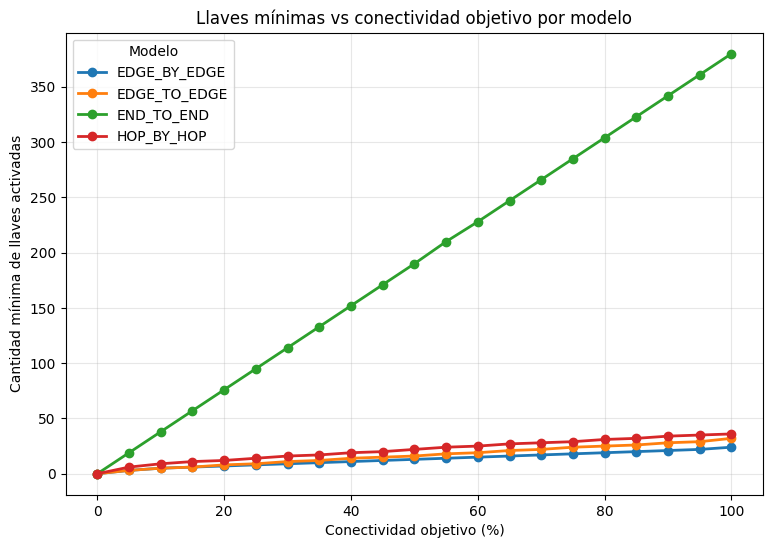

In [32]:
#| echo: false
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

for model_name, group in df_m2.groupby("model"):
    group = group.sort_values("target_connectivity_pct")
    plt.plot(
        group["target_connectivity_pct"],
        group["selected_keys"],
        marker="o",
        linewidth=2,
        label=model_name,
    )

plt.xlabel("Conectividad objetivo (%)")
plt.ylabel("Cantidad mínima de llaves activadas")
plt.title("Llaves mínimas vs conectividad objetivo por modelo")
plt.grid(True, alpha=0.3)
plt.legend(title="Modelo")
plt.show()


## Minimizar llaves garantizando al menos 1 camino por par


:::: {layout="[0.5, 0.5]"}

:::{#firstcol}

\begin{aligned}
P &: \text{conjunto de pares origen-destino alcanzables de la red} \\
R_p &: \text{conjunto de rutas candidatas para el par } p \in P \\
R &= \bigcup_{p \in P} R_p \\
K &: \text{conjunto de llaves candidatas disponibles} \\
S_r &\subseteq K : \text{conjunto de llaves requeridas por la ruta } r \in R \\
\end{aligned}
$$
x_r =
\begin{cases}
1 & \text{si se selecciona la ruta } r \\
0 & \text{en otro caso}
\end{cases}
\qquad
y_k =
\begin{cases}
1 & \text{si se dispone la llave } k \\
0 & \text{en otro caso}
\end{cases}
$$
:::

:::{#secondcol}


\begin{aligned}
\min \quad & \sum_{k \in K} y_k \\
\text{s.a.} \quad
& \sum_{k \in S_r} y_k \ge |S_r|\,x_r \qquad \forall r \in R \\
& 1 \le \sum_{r \in R_p} x_r \qquad \forall p \in P \\
& x_r \in \{0,1\} \qquad \forall r \in R \\
& y_k \in \{0,1\} \qquad \forall k \in K \\
\end{aligned}

:::


::::


In [33]:
import pandas as pd


df_m3 = pd.DataFrame()

for sec_model in SERIES_COLORS.keys():
    from models.model3_min_keys_full_connectivity import solve_for_security_model
    
    df_m3 = pd.concat([df_m3, solve_for_security_model(result,sec_model)], ignore_index=True)

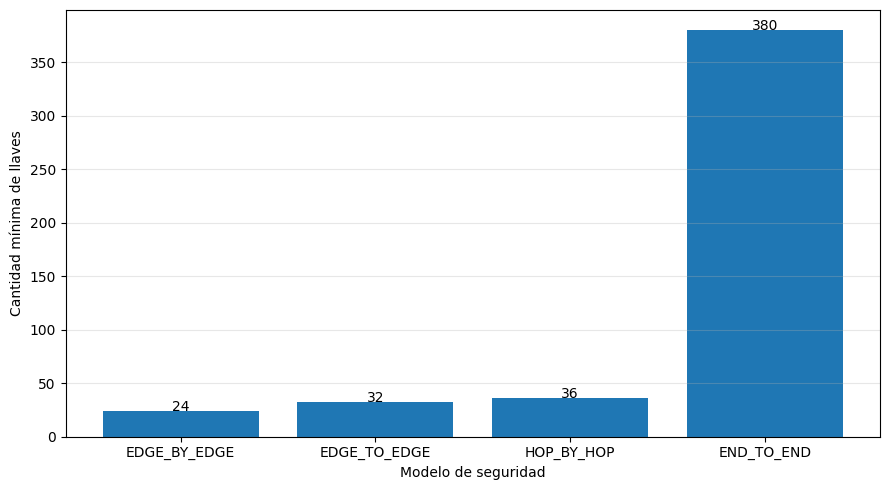

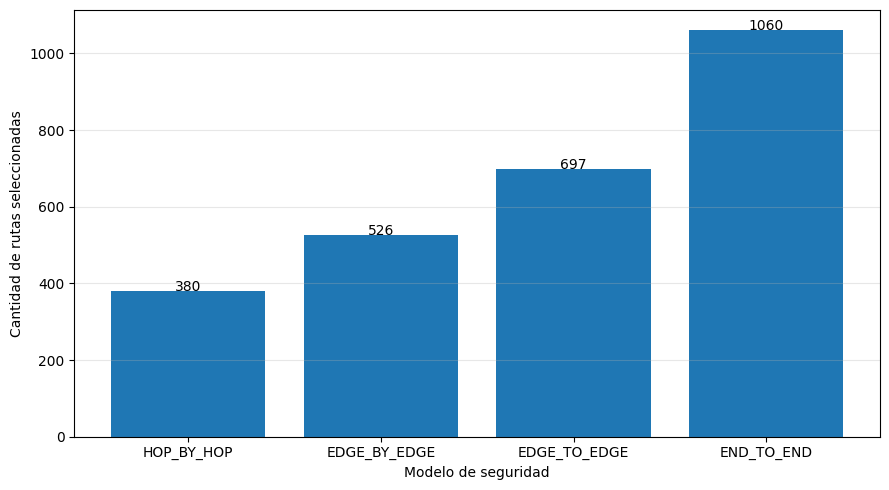

In [34]:
#| label: fig-gapminder
#| fig-cap: "Resultados de modelo 3"
#| fig-subcap:
#|   - "Llaves mínimas para garantizar al menos 1 camino por par"
#|   - "Rutas seleccionadas en la solución óptima"
#| layout-ncol: 2
#| column: page
#| echo: false
#| out-width: 100%

import matplotlib.pyplot as plt

plot_df = df_m3.sort_values("selected_keys").copy()

plt.figure(figsize=(9, 5))
plt.bar(plot_df["model"], plot_df["selected_keys"])
plt.xlabel("Modelo de seguridad")
plt.ylabel("Cantidad mínima de llaves")
plt.grid(axis="y", alpha=0.3)

for i, value in enumerate(plot_df["selected_keys"]):
    plt.text(i, value + 0.05, str(value), ha="center")

plt.tight_layout()
plt.show()

plot_df = df_m3.sort_values("selected_routes").copy()

plt.figure(figsize=(9, 5))
plt.bar(plot_df["model"], plot_df["selected_routes"])
plt.xlabel("Modelo de seguridad")
plt.ylabel("Cantidad de rutas seleccionadas")
plt.grid(axis="y", alpha=0.3)

for i, value in enumerate(plot_df["selected_routes"]):
    plt.text(i, value + 0.05, str(value), ha="center")

plt.tight_layout()
plt.show()
